This code calculates the spatial hazard index (SHI) for surface and seafloor environments.

inputs needed: 
- MHW metrics nc files
- 50th climatology 


outputs: 
- SHI nc files 
- shi surface and seafloor maps: figure 2 and figure 3 

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import pandas as pd
import xarray as xr

In [2]:
# set up directories
BASE_DIR = Path("C:/Users/shw1/Documents/GitHub/MHW_risk_framework")

MHW_METRICS_DIR = BASE_DIR / "data" / "MHW_metrics"
SHI_OUT_DIR = BASE_DIR / "data" / "SHI"

# bathy file used for depth band plots (bathy from roms model)
BATHY_FILE = BASE_DIR / "data" / "roms_mask_0_250m.nc"

# create three distinct oceanographic regions
REGIONS = {
    "EAC_jet" : {"label": "EAC jet","lat_bounds": (-32, -29), "lon_bounds": (152, 154.5)},
    "Separation_zone" : {"label": "Separation zone", "lat_bounds": (-35, -32), "lon_bounds": (150.75, 153.25)},
    "Southern_extension" : {"label": "Southern extension", "lat_bounds": (-38, -35), "lon_bounds": (149.5, 152)}
}

DOMAINS = ["surface", "seafloor"]

# secondary weigthings of seasonality and long-term warming (from sensitivity analysis notebooks)

SEASONAL_ALPHA = 0.10

WARMING_BETA = 1

# weightings for frequency, duration and intensity metrics (can be alter for application to different ecological communities)
COMPONENT_WEIGHTS = {
    "frequency": 1.0,
    "duration": 1.0,
    "intensity": 1.0,
}

In [3]:
# functions
def standardize_region(da: xr.DataArray, mask: xr.DataArray | None = None) -> xr.DataArray:
    if mask is not None:
        da = da.where(mask)
    mean = da.mean(skipna=True)
    std = da.std(skipna=True)
    return xr.where(std > 0, (da - mean) / std, np.nan)

def drop_nuisance_coords(da: xr.DataArray) -> xr.DataArray:
    drop_these = [c for c in ["ocean_time", "quantile", "band", "crs"] if c in da.coords and c not in da.dims]
    return da.reset_coords(drop_these, drop=True) if drop_these else da



def align_doy_to_time(
    doy_da: xr.DataArray,
    time: xr.DataArray,
) -> xr.DataArray:
    doy_da = ensure_day_of_year_name(drop_nuisance_coords(doy_da))
    doy = time.dt.dayofyear
    doy = xr.where(time.dt.is_leap_year & (doy > 59), doy - 1, doy,)
    index = xr.DataArray((doy - 1).astype("int32").data, dims=["time"], coords={"time": time},)
    aligned = doy_da.isel(day_of_year=index)
    return (
        aligned
        .reset_coords("day_of_year", drop=True)
        .assign_coords(time=time)
    )


def ensure_day_of_year_name(da: xr.DataArray) -> xr.DataArray:
    for cand in ["day_of_year", "doy", "DOY", "DAY_OF_YEAR", "ocean_time", "time", "doy365"]:
        if cand in da.dims:
            if cand != "day_of_year":
                da = da.rename({cand: "day_of_year"})
            return da.assign_coords(day_of_year=np.arange(1, da.sizes["day_of_year"] + 1))
    raise ValueError(f"No day-of-year dimension found in {da.dims}")


def time_to_years(time_da: xr.DataArray) -> xr.DataArray:
    values = ((time_da.values - time_da.values[0]) / np.timedelta64(1, "D")) / 365.25
    return xr.DataArray(values, dims=["time"], coords={"time": time_da})


def _safe_slope_1d(y: np.ndarray, x: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(y) & np.isfinite(x)

    if valid.sum() < 10:
        return np.nan

    return float(np.polyfit(x[valid], y[valid], 1)[0])


def calculate_trend_map(temp: xr.DataArray, *, time_dim: str = "time") -> xr.DataArray:
    if time_dim != "time":
        temp = temp.rename({time_dim: "time"})

    x = time_to_years(temp["time"])

    trend = xr.apply_ufunc(
        _safe_slope_1d,
        temp,
        x,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    return trend


In [4]:
# calculate seasonal weighting (to apply to duration and intensity metrics)

def calculate_seasonality_term(
    clim50: xr.DataArray,
    *,
    alpha: float = SEASONAL_ALPHA,
    mask: xr.DataArray | None = None,
) -> xr.Dataset:

    clim50 = ensure_day_of_year_name(clim50)
    clim50 = drop_nuisance_coords(clim50)

    if clim50.chunks is not None:
        clim50 = clim50.chunk({"day_of_year": -1})

    q95 = drop_nuisance_coords(
        clim50.quantile(0.95, dim="day_of_year", skipna=True)
    )
    q05 = drop_nuisance_coords(
        clim50.quantile(0.05, dim="day_of_year", skipna=True)
    )
    A = q95 - q05

    if mask is not None:
        A = A.where(mask)

    A_max_da = A.max(skipna=True)
    A_max = float(A_max_da.compute()) if hasattr(A_max_da, "compute") else float(A_max_da)
    if not np.isfinite(A_max) or A_max <= 0:
        raise ValueError("Seasonal amplitude maximum must be finite and positive.")

    # Linear scaling within the current region-domain dataset retains
    # proportional amplitude differences without exponential saturation.
    S = A / A_max
    S = S.clip(0, 1).where(np.isfinite(A))

    Tmin =  clim50.min("day_of_year", skipna=True)
    Tmax = clim50.max("day_of_year", skipna=True)
    denom = Tmax - Tmin

    h = xr.where(
        np.isfinite(denom) & (denom > 0),
        2 * ((clim50 - Tmin) / denom) - 1,
        0.0,
    ).clip(-1, 1)

    seasonal_weight_doy = 1 + alpha * S * h
    seasonal_weight_doy = seasonal_weight_doy / seasonal_weight_doy.mean("day_of_year", skipna=True)
    seasonal_weight_doy = seasonal_weight_doy.where(np.isfinite(A))

    return xr.Dataset(
        {
            "seasonality_amplitude_A": A.astype("float32"),
            "seasonality_strength_S": S.astype("float32"),
            "seasonal_position_h": h.astype("float32"),
            "seasonal_weight_doy": seasonal_weight_doy.astype("float32"),
        },
        attrs={
            "A_max": A_max,
            "alpha": alpha,
            "strength_formula": "S = A / A_max within region and domain",
            "weight_formula": "w = 1 + alpha * S * h, normalised to annual mean one",
            "description": "Linearly scaled seasonality terms used to weight MHW duration and intensity.",
        },
    )

In [5]:
# weighted metrics
def _seasonally_adjusted_event_metrics_1d(
    event: np.ndarray,
    positive_anomaly: np.ndarray,
    seasonal_weight: np.ndarray,
    years: np.ndarray,
) -> np.ndarray:
    event = np.asarray(event, dtype=bool)
    anomaly = np.asarray(positive_anomaly, dtype=float)
    weight = np.asarray(seasonal_weight, dtype=float)
    years = np.asarray(years)

    n_years = np.unique(years).size
    event_durations = []
    event_intensities = []

    i = 0
    while i < event.size:
        if not event[i]:
            i += 1
            continue

        j = i
        while j < event.size and event[j]:
            j += 1

        event_weight = weight[i:j]
        event_anomaly = anomaly[i:j]

        valid_duration = np.isfinite(event_weight)
        event_durations.append(
            float(event_weight[valid_duration].sum())
            if valid_duration.any() else np.nan
        )

        positive = (
            np.isfinite(event_anomaly)
            & np.isfinite(event_weight)
            & (event_anomaly > 0)
        )
        event_intensities.append(
            float(np.mean(event_anomaly[positive] * event_weight[positive]))
            if positive.any() else 0.0
        )
        i = j

    n_events = len(event_durations)
    if n_events == 0:
        return np.array([0.0, 0.0, 0.0], dtype=float)

    return np.array([
        n_events / n_years,
        np.nanmean(event_durations),
        np.nanmean(event_intensities),
    ], dtype=float)


def calculate_weighted_mhw_metrics(
    event_mask: xr.DataArray,
    positive_anomaly: xr.DataArray,
    seasonal_weight_time: xr.DataArray,
) -> xr.Dataset:
    event_mask, positive_anomaly, seasonal_weight_time = xr.align(
        event_mask.fillna(False).astype(bool),
        positive_anomaly,
        seasonal_weight_time,
        join="exact",
    )
    years = xr.DataArray(
        event_mask.time.dt.year
    )
    metrics = xr.apply_ufunc(
        _seasonally_adjusted_event_metrics_1d,
        event_mask, positive_anomaly, seasonal_weight_time, years,
        input_core_dims=[["time"], ["time"], ["time"], ["time"]],
        output_core_dims=[["metric"]],
        vectorize=True, dask="parallelized", output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"metric": 3}},
    ).assign_coords(metric=[
        "F_over_T", "D_bar_weighted_days", "I_bar_weighted_degC",
    ])
    return metrics.to_dataset(
        dim="metric"
    ).astype("float32")


In [6]:
# warming modifier
def calculate_warming_modifier(
    temp: xr.DataArray,
    mask: xr.DataArray,
) -> xr.Dataset:
    trend = calculate_trend_map(temp, time_dim="time").where(mask)
    mean_trend = float(trend.mean(skipna=True).compute().item())
    if not np.isfinite(mean_trend) or np.isclose(mean_trend, 0.0):
        raise ValueError("Regional mean trend must be finite and different from zero.")
    warming_modifier = (
        1 + WARMING_BETA * (trend / mean_trend)
    ).where(mask)
    return xr.Dataset({
        "temperature_trend_degC_per_year": trend.astype("float32"),
        "warming_modifier": warming_modifier.astype("float32"),
    })

In [7]:
# SHI calculation
def calculate_shi(
    F_over_T: xr.DataArray,
    D_bar_weighted: xr.DataArray,
    I_bar_weighted: xr.DataArray,
    warming_modifier: xr.DataArray,
    mask: xr.DataArray,
) -> xr.Dataset:
    F, D, I, W, mask = xr.align(
        F_over_T, D_bar_weighted, I_bar_weighted,
        warming_modifier, mask, join="exact",
    )
    Fz = standardize_region(F, mask)
    Dz = standardize_region(D, mask)
    Iz = standardize_region(I, mask)

    exposure = (
        COMPONENT_WEIGHTS["frequency"] * Fz
        + COMPONENT_WEIGHTS["duration"] * Dz
        + COMPONENT_WEIGHTS["intensity"] * Iz
    )
    risk_raw = (exposure * W).where(mask)
    shi = standardize_region(risk_raw, mask)

    return xr.Dataset(
        {
            "SHI": shi.astype("float32"),
            "exposure": exposure.astype("float32"),
            "risk_raw": risk_raw.astype("float32"),
            "F_z": Fz.astype("float32"),
            "D_z": Dz.astype("float32"),
            "I_z": Iz.astype("float32"),
        }
    )

In [8]:
# SHI calculation


def process_shi(
    *,
    domain: str,
    region_name: str,
) -> xr.Dataset:
    print(f"Processing SHI for {domain} {region_name}...")
    path = MHW_METRICS_DIR / f"{domain}_{region_name}_mhw_metrics.nc"
    ds = xr.open_dataset(path)

    mask = ds["mask"] == 1
    clim50 = ds["clim50"]
    temp = ds["temperature"]
    event_mask = ds["event_mask"] == 1
    positive_anomaly = ds["positive_intensity_anomaly"]

    seasonality = calculate_seasonality_term(
        clim50,
        alpha=SEASONAL_ALPHA,
        mask=mask,
    )

    seasonal_weight_time = align_doy_to_time(seasonality["seasonal_weight_doy"], temp.time)

    weighted_metrics = calculate_weighted_mhw_metrics(
        event_mask,
        positive_anomaly,
        seasonal_weight_time,
    ).where(mask)

    warming = calculate_warming_modifier(
        temp,
        mask,
    )

    shi = calculate_shi(
        weighted_metrics["F_over_T"],
        weighted_metrics["D_bar_weighted_days"],
        weighted_metrics["I_bar_weighted_degC"],
        warming["warming_modifier"],
        mask,
    )

    ds_out = xr.merge([
            seasonality,
            weighted_metrics,
            warming,
            shi,
            xr.Dataset({"mask": mask.astype("int8")}),
        ])
    return ds_out

In [9]:
# Surface
surface_EAC_jet = process_shi(domain="surface", region_name="EAC_jet")

surface_Separation_zone = process_shi(domain="surface", region_name="Separation_zone")

surface_Southern_extension = process_shi(domain="surface", region_name="Southern_extension")

# Seafloor
seafloor_EAC_jet = process_shi(domain="seafloor", region_name="EAC_jet")

seafloor_Separation_zone = process_shi(domain="seafloor", region_name="Separation_zone")

seafloor_Southern_extension = process_shi(domain="seafloor", region_name="Southern_extension")

shi_outputs = {
    "surface": {
        "EAC_jet": surface_EAC_jet,
        "Separation_zone": surface_Separation_zone,
        "Southern_extension": surface_Southern_extension,
    },
    "seafloor": {
        "EAC_jet": seafloor_EAC_jet,
        "Separation_zone": seafloor_Separation_zone,
        "Southern_extension": seafloor_Southern_extension,
    },
}

Processing SHI for surface EAC_jet...


c:\Users\shw1\AppData\Local\anaconda3\envs\MHW_risk2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Processing SHI for surface Separation_zone...


c:\Users\shw1\AppData\Local\anaconda3\envs\MHW_risk2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Processing SHI for surface Southern_extension...


...

c:\Users\shw1\AppData\Local\anaconda3\envs\MHW_risk2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Processing SHI for seafloor Separation_zone...


c:\Users\shw1\AppData\Local\anaconda3\envs\MHW_risk2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Processing SHI for seafloor Southern_extension...


c:\Users\shw1\AppData\Local\anaconda3\envs\MHW_risk2\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


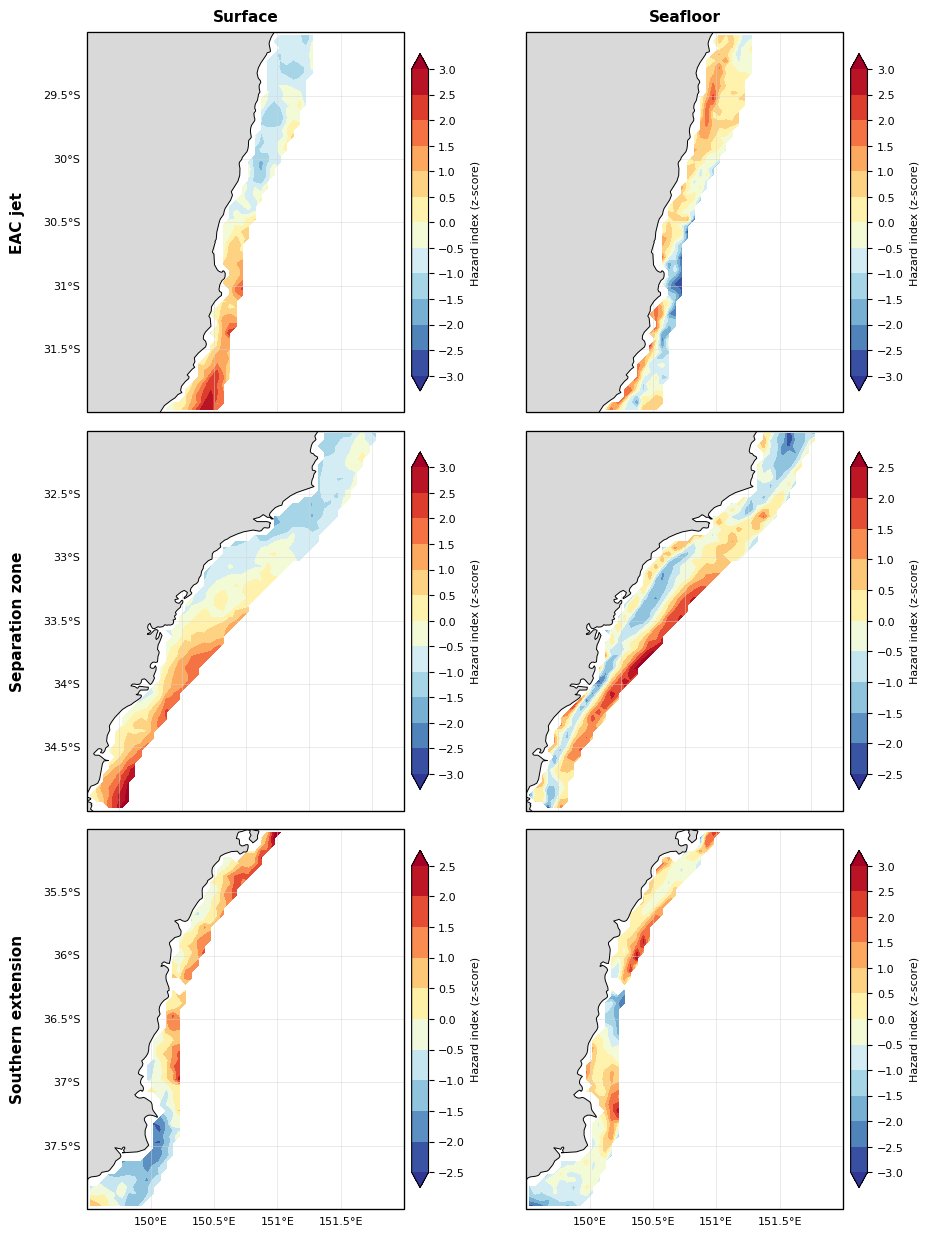

In [10]:
# plotting
surface_sri_by_region = {
    region_name: {"sri": shi_outputs["surface"][region_name]["SHI"]}
    for region_name in REGIONS
    if region_name in shi_outputs.get("surface", {})
}

sri_by_region = {
    region_name: {"sri": shi_outputs["seafloor"][region_name]["SHI"]}
    for region_name in REGIONS
    if region_name in shi_outputs.get("seafloor", {})
}

regions = REGIONS

CMAP = "RdYlBu_r"
ROBUST_PCTL = 99
MIN_VMAX_ABS = 0.5
TICK_STEP = 0.5

plot_regions = [
    "EAC_jet",
    "Separation_zone",
    "Southern_extension",
]

fig, axes = plt.subplots(
    nrows=len(plot_regions),
    ncols=2,
    figsize=(9, 12.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

if len(plot_regions) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, region_name in enumerate(plot_regions):
    if region_name not in surface_sri_by_region:
        print(f"Skipping {region_name}: missing surface SHI")
        continue

    if region_name not in sri_by_region:
        print(f"Skipping {region_name}: missing seafloor SHI")
        continue

    panel_specs = [
        ("surface", surface_sri_by_region[region_name]["sri"]),
        ("seafloor", sri_by_region[region_name]["sri"]),
    ]

    for j, (domain_name, shi_da) in enumerate(panel_specs):
        ax = axes[i, j]

        if "s_rho" in shi_da.dims:
            shi_da = shi_da.squeeze("s_rho", drop=True)

        valid = np.asarray(
            shi_da.values[np.isfinite(shi_da.values)]
        )

        if valid.size == 0:
            vmax = 1.0
        else:
            vmax = np.nanpercentile(
                np.abs(valid),
                ROBUST_PCTL,
            )
            vmax = max(vmax, MIN_VMAX_ABS)

        vmax = np.ceil(vmax / TICK_STEP) * TICK_STEP

        levels = np.arange(
            -vmax,
            vmax + TICK_STEP,
            TICK_STEP,
        )
        cbar_ticks = levels.copy()

        if len(levels) < 2:
            levels = np.array(
                [-1, 0, 1],
                dtype=float,
            )
            cbar_ticks = levels.copy()

        lat_name = "latitude"
        lon_name = "longitude"

        if (
            lat_name not in shi_da.coords
            or lon_name not in shi_da.coords
        ):
            raise ValueError(
                "Expected coordinates 'latitude' and "
                f"'longitude', but found: {list(shi_da.coords)}"
            )

        mesh = ax.contourf(
            shi_da[lon_name],
            shi_da[lat_name],
            shi_da,
            levels=levels,
            cmap=CMAP,
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        ax.add_feature(
            cfeature.LAND,
            facecolor="#d9d9d9",
            edgecolor="none",
            zorder=3,
        )

        ax.coastlines(
            resolution="10m",
            linewidth=0.7,
            color="black",
            zorder=5,
        )

        bounds = regions[region_name]
        lat0, lat1 = bounds["lat_bounds"]
        lon0, lon1 = bounds["lon_bounds"]

        ax.set_extent(
            [lon0, lon1, lat0, lat1],
            crs=ccrs.PlateCarree(),
        )

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.4,
            color="lightgray",
            alpha=0.8,
            linestyle="-",
        )

        gl.top_labels = False
        gl.right_labels = False

        if j > 0:
            gl.left_labels = False

        if i < len(plot_regions) - 1:
            gl.bottom_labels = False

        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

        border = Rectangle(
            (0, 0),
            1,
            1,
            transform=ax.transAxes,
            fill=False,
            edgecolor="black",
            linewidth=0.9,
            zorder=30,
            clip_on=False,
        )
        ax.add_patch(border)

        region_label = REGIONS[region_name].get(
            "label",
            region_name.replace("_", " "),
        )

        if i == 0:
            column_title = (
                "Surface"
                if domain_name == "surface"
                else "Seafloor"
            )
            ax.set_title(
                column_title,
                fontsize=11,
                fontweight="bold",
                pad=8,
            )
        else:
            ax.set_title("")

        if j == 0:
            ax.text(
                -0.22,
                0.5,
                region_label,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=11,
                fontweight="bold",
            )

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            orientation="vertical",
            shrink=0.88,
            pad=0.02,
            ticks=cbar_ticks,
        )

        cbar.set_label(
            "Hazard index (z-score)",
            fontsize=8,
        )
        cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
fig.subplots_adjust(wspace=0.15)
plt.show()

In [11]:

plot_regions = [
    "EAC_jet",
    "Separation_zone",
    "Southern_extension",
]

DEPTH_BANDS = [30, 50, 70, 90, 110, 130, 150, 170, 190]
DEPTH_TOLERANCE = 10
MIN_N = 2

SURFACE_COLOUR = "#3B8EA5"
SEAFLOOR_COLOUR = "#C23B3B"
CONNECTOR_COLOUR = "0.55"
SMALL_DIFF = 0.25


def drop_nonspatial_dims(
    da: xr.DataArray,
    lat_name: str = "latitude",
    lon_name: str = "longitude",
) -> xr.DataArray:
    """Select the first index of any remaining non-spatial dimension."""
    for dim in list(da.dims):
        if dim not in [lat_name, lon_name]:
            da = da.isel({dim: 0}, drop=True)
    return da


def get_bathymetry_da() -> xr.DataArray:
    """Load the two-dimensional bathymetry grid."""
    bathy_ds = xr.open_dataset(BATHY_FILE)

    variable_candidates = [
        "h",
        "depth_m",
        "bathymetry",
        "seafloor_depth",
        "depth",
    ]

    for variable_name in variable_candidates:
        if variable_name in bathy_ds:
            print(
                f"Using bathymetry variable "
                f"'{variable_name}' from {BATHY_FILE}"
            )
            return bathy_ds[variable_name]

    raise ValueError(
        "No recognised bathymetry variable found. "
        f"Available variables: {list(bathy_ds.data_vars)}"
    )


def subset_to_region(
    da: xr.DataArray,
    region_name: str,
    lat_name: str = "latitude",
    lon_name: str = "longitude",
) -> xr.DataArray:
    """Mask a DataArray to the latitude and longitude bounds of a region."""
    bounds = REGIONS[region_name]
    lat0, lat1 = bounds["lat_bounds"]
    lon0, lon1 = bounds["lon_bounds"]

    region_mask = (
        (da[lat_name] >= min(lat0, lat1))
        & (da[lat_name] <= max(lat0, lat1))
        & (da[lon_name] >= min(lon0, lon1))
        & (da[lon_name] <= max(lon0, lon1))
    )

    return da.where(region_mask)


def extract_depth_band_values(
    surface_da: xr.DataArray,
    seafloor_da: xr.DataArray,
    depth_da: xr.DataArray,
    depth_mid: float,
    depth_tol: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Extract paired surface and seafloor SHI values for one depth band."""
    depth_mask = (
        (depth_da >= depth_mid - depth_tol)
        & (depth_da <= depth_mid + depth_tol)
    )

    surface_values = surface_da.where(depth_mask).values.ravel()
    seafloor_values = seafloor_da.where(depth_mask).values.ravel()

    valid = (
        np.isfinite(surface_values)
        & np.isfinite(seafloor_values)
    )

    return surface_values[valid], seafloor_values[valid]


surface_shi_by_region = {
    region_name: shi_outputs["surface"][region_name]["SHI"]
    for region_name in REGIONS
    if region_name in shi_outputs.get("surface", {})
}

seafloor_shi_by_region = {
    region_name: shi_outputs["seafloor"][region_name]["SHI"]
    for region_name in REGIONS
    if region_name in shi_outputs.get("seafloor", {})
}

bathy = get_bathymetry_da()
bathy = drop_nonspatial_dims(bathy)
depth_abs = np.abs(bathy)

records = []

for region_name in plot_regions:
    if (
        region_name not in surface_shi_by_region
        or region_name not in seafloor_shi_by_region
    ):
        print(
            f"Skipping {region_name}: "
            "missing surface or seafloor SHI"
        )
        continue

    region_label = REGIONS[region_name].get(
        "label",
        region_name.replace("_", " "),
    )

    surface_shi = drop_nonspatial_dims(
        surface_shi_by_region[region_name]
    )
    seafloor_shi = drop_nonspatial_dims(
        seafloor_shi_by_region[region_name]
    )

    surface_region, seafloor_region, depth_region = xr.align(
        subset_to_region(surface_shi, region_name),
        subset_to_region(seafloor_shi, region_name),
        subset_to_region(depth_abs, region_name),
        join="inner",
    )

    for depth_mid in DEPTH_BANDS:
        surface_values, seafloor_values = extract_depth_band_values(
            surface_region,
            seafloor_region,
            depth_region,
            depth_mid,
            DEPTH_TOLERANCE,
        )

        n = len(surface_values)

        if n < MIN_N:
            continue

        surface_median = np.nanmedian(surface_values)
        seafloor_median = np.nanmedian(seafloor_values)
        surface_mean = np.nanmean(surface_values)
        seafloor_mean = np.nanmean(seafloor_values)

        records.append({
            "Region": region_label,
            "Region_name": region_name,
            "Depth_m": depth_mid,
            "n": n,
            "surface_median": surface_median,
            "seafloor_median": seafloor_median,
            "delta_median": seafloor_median - surface_median,
            "abs_delta_median": abs(
                seafloor_median - surface_median
            ),
            "surface_mean": surface_mean,
            "seafloor_mean": seafloor_mean,
            "delta_mean": seafloor_mean - surface_mean,
            "abs_delta_mean": abs(
                seafloor_mean - surface_mean
            ),
        })

profile_df = pd.DataFrame(records)

Using bathymetry variable 'depth_m' from C:\Users\shw1\Documents\GitHub\MHW_risk_framework\data\roms_mask_0_250m.nc


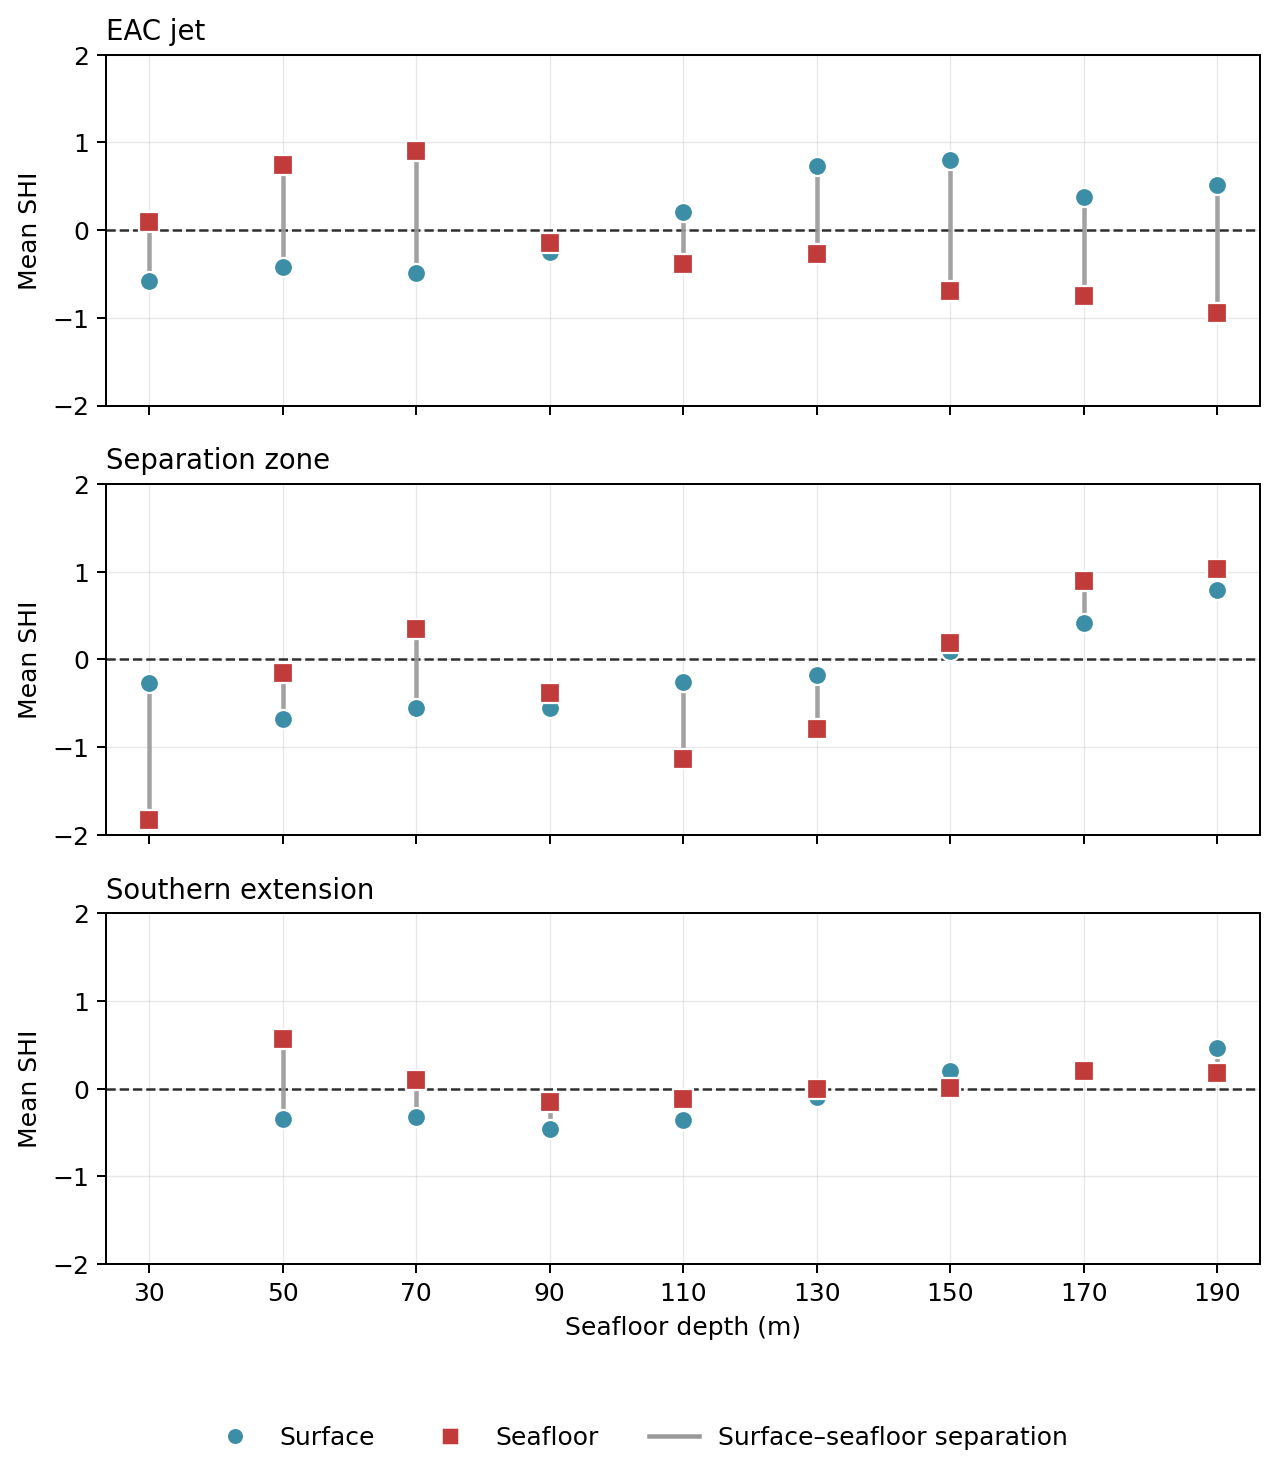

In [12]:
region_order = [
    REGIONS[region_name].get(
        "label",
        region_name.replace("_", " "),
    )
    for region_name in plot_regions
]

fig, axes = plt.subplots(
    nrows=len(region_order),
    ncols=1,
    figsize=(7.2, 8.4),
    dpi=180,
    sharex=True,
    sharey=True,
)

if len(region_order) == 1:
    axes = [axes]

CONNECTOR_COLOUR = "0.60"

for ax, region in zip(axes, region_order):
    sub = (
        profile_df
        .loc[profile_df["Region"] == region]
        .sort_values("Depth_m")
    )

    ax.set_axisbelow(True)

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=1,
    )

    if sub.empty:
        ax.set_title(
            region,
            fontsize=11,
            loc="left",
        )
        continue

    for _, row in sub.iterrows():
        depth = row["Depth_m"]
        surface_mean = row["surface_mean"]
        seafloor_mean = row["seafloor_mean"]

        ax.plot(
            [depth, depth],
            [surface_mean, seafloor_mean],
            color=CONNECTOR_COLOUR,
            linewidth=1.8,
            alpha=0.9,
            zorder=2,
        )

        ax.scatter(
            depth,
            surface_mean,
            s=58,
            marker="o",
            color=SURFACE_COLOUR,
            edgecolor="white",
            linewidth=0.9,
            zorder=3,
        )

        ax.scatter(
            depth,
            seafloor_mean,
            s=62,
            marker="s",
            color=SEAFLOOR_COLOUR,
            edgecolor="white",
            linewidth=0.9,
            zorder=3,
        )

    ax.set_title(
        region,
        fontsize=11,
        loc="left",
    )

    ax.grid(
        True,
        which="major",
        axis="both",
        linewidth=0.5,
        alpha=0.30,
    )

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)
        ax.spines[side].set_color("black")

for ax in axes:
    ax.set_ylabel("Mean SHI")

axes[-1].set_xlabel("Seafloor depth (m)")

if not profile_df.empty:
    x_min = profile_df["Depth_m"].min()
    x_max = profile_df["Depth_m"].max()
    x_pad = max((x_max - x_min) * 0.04, 1)

    depth_ticks = sorted(
        profile_df["Depth_m"]
        .dropna()
        .unique()
    )

    y_values = np.concatenate([
        profile_df[
            "surface_mean"
        ].dropna().to_numpy(),
        profile_df[
            "seafloor_mean"
        ].dropna().to_numpy(),
    ])

    y_step = 1

    y_limit = (
        np.ceil(
            np.max(np.abs(y_values))
            / y_step
        )
        * y_step
    )

    y_ticks = np.arange(
        -y_limit,
        y_limit + y_step,
        y_step,
    )

    for ax in axes:
        ax.set_xlim(
            x_min - x_pad,
            x_max + x_pad,
        )
        ax.set_xticks(depth_ticks)
        ax.set_ylim(
            -y_limit,
            y_limit,
        )
        ax.set_yticks(y_ticks)

surface_handle = plt.Line2D(
    [0],
    [0],
    marker="o",
    linestyle="None",
    color="none",
    markerfacecolor=SURFACE_COLOUR,
    markeredgecolor="white",
    markersize=7,
    label="Surface",
)

seafloor_handle = plt.Line2D(
    [0],
    [0],
    marker="s",
    linestyle="None",
    color="none",
    markerfacecolor=SEAFLOOR_COLOUR,
    markeredgecolor="white",
    markersize=7,
    label="Seafloor",
)

connector_handle = plt.Line2D(
    [0],
    [0],
    color=CONNECTOR_COLOUR,
    linewidth=1.8,
    label="Surface–seafloor separation",
)

fig.legend(
    handles=[
        surface_handle,
        seafloor_handle,
        connector_handle,
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

plt.tight_layout(
    rect=[0, 0.06, 1, 0.97]
)

plt.show()